In [77]:
from typing import TypedDict, Dict, List
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [78]:
class State(TypedDict):
    name: str
    number: int
    guess: int
    max_guesses: int
    attempt: int
    lowerlimit: int
    upperlimit: int
    result: str
    hint: str

In [79]:
import random

def setup(state: State) -> State:
    state["attempt"] = 0
    state["number"] = random.randint(0, 20)
    print(f"Hello {state['name']}, the number to be guessed is: {state['number']}. Let's begin !!!")
    return state

def guess(state: State) -> State:
    state["guess"] = random.randint(0, 20)
    state["attempt"] += 1
    print("Attempt", state["attempt"], "number is: ", state["guess"])
    return state

def router(state: State) -> State:
    if state["guess"] == state["number"]:
        print("Number found: ", state["guess"])
        return "end"
    elif state["attempt"] > state["max_guesses"]:
        print("Attempts overshot") 
        return "end"
    else:
        return "previous"

In [80]:
graph = StateGraph(State)
graph.set_entry_point("Setup")
graph.add_node("Setup", setup)
graph.add_node("Guess", guess)
graph.add_edge("Setup", "Guess")
graph.add_node("Router", lambda state:state)
graph.add_edge("Guess","Router")
graph.add_conditional_edges(
    "Router", 
    router,
    {
        "previous": "Guess",
        "end": END
    }
)

In [81]:
app = graph.compile()

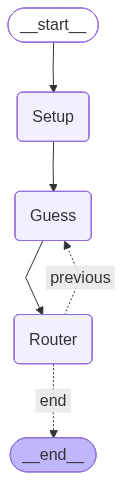

In [82]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [85]:
Outcome = app.invoke({"name": "Student", "max_guesses": 7})
Outcome

Hello Student, the number to be guessed is: 1. Let's begin !!!
Attempt 1 number is:  9
Attempt 2 number is:  10
Attempt 3 number is:  9
Attempt 4 number is:  19
Attempt 5 number is:  18
Attempt 6 number is:  8
Attempt 7 number is:  13
Attempt 8 number is:  12
Attempts overshot


{'name': 'Student', 'number': 1, 'guess': 12, 'max_guesses': 7, 'attempt': 8}